# 02 – Bull & Bear Labeling

---

## Vad gör vi i den här notebooken?

Innan vi kan träna några modeller behöver vi definiera vad som räknas som en **bull-** respektive **bear-marknad**. Vi använder Lunde & Timmermann (2004)-algoritmen (LT) — en regelbaserad, icke-parametrisk metod som identifierar lokala toppar och bottnar i prisserien:

**SP500**

- 🔴 **Bear market** – en lokal botten hittas om priset fallit **10% eller mer** från senaste topp
- 🟢 **Bull market** – en lokal topp hittas om priset stigit **15% eller mer** från senaste botten

**Bitcoin**

- 🔴 **Bear market** – en lokal botten hittas om priset fallit **60% eller mer** från senaste topp
- 🟢 **Bull market** – en lokal topp hittas om priset stigit **60% eller mer** från senaste botten
| Tillgång | Bear-tröskel | Bull-tröskel |
|----------|-------------|-------------|
| S&P 500  | -10%        | +15%        |
| Bitcoin  | -60%        | +60%        |

Bitcoin använder en högre tröskel eftersom 10%-rörelser är normalt brus för kryptovalutor. De historiska bear markets har sett nedgångar på 70–86%.

Dessa etiketter fungerar som vår **ground truth** – det vi vill säga det "rätta svaret" som alla modeller sedan tränas och utvärderas mot.

**Input:** `data/sp500.csv`, `data/bitcoin.csv`  
**Output:** `data/sp500_labeled.csv`, `data/bitcoin_labeled.csv`

## 1. Importera bibliotek

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR    = '../data'
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ Bibliotek importerade')

✓ Bibliotek importerade


## 2. Läs in data

Vi läser in de separata CSV-filerna som skapades i `01_data_collection.ipynb`.

In [2]:
assets = {}

files = {
    'SP500':   'sp500.csv',
    'Bitcoin': 'bitcoin.csv',
}

for name, filename in files.items():
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, index_col='Date', parse_dates=True)
    assets[name] = df
    print(f'✓ {name}: {len(df)} rader ({df.index.min().date()} → {df.index.max().date()})')

✓ SP500: 6539 rader (2000-01-03 → 2025-12-31)
✓ Bitcoin: 4124 rader (2014-09-17 → 2025-12-31)


## 3. Definiera långsiktig bull/bear-regel

### Hur fungerar algoritmen?

Vi implementerar Lunde & Timmermann (2004)-algoritmen (LT) som går igenom priset dag för dag och håller koll på:
- Den senaste **toppen** (peak) – används för att detektera bear market
- Den senaste **botten** (trough) – används för att detektera bull market

Trösklar per tillgång:
- **S&P 500:** bear om priset faller ≥10% från topp, bull om priset stiger ≥15% från botten
- **Bitcoin:** bear om priset faller ≥60% från topp, bull om priset stiger ≥60% från botten

Resultatet är en kolumn med `1` (bull) eller `0` (bear) för varje dag.

In [11]:
def label_regimes(prices: pd.Series,
                  bear_threshold=0.10,
                  bull_threshold=0.15) -> pd.Series:
    """
    Lunde & Timmermann (2004) algoritmen.
    Bear: priset faller bear_threshold från senaste topp → ny botten hittad.
    Bull: priset stiger bull_threshold från senaste botten → ny topp hittad.
    """
    labels = pd.Series(index=prices.index, dtype=int, name='Regime')
    regime = 1        # Startar i bull
    peak   = prices.iloc[0]
    trough = prices.iloc[0]

    for date, price in prices.items():
        if regime == 1:  # Bull market
            if price > peak:
                peak = price
            if (price - peak) / peak <= -bear_threshold:
                regime = 0
                trough = price
        else:            # Bear market
            if price < trough:
                trough = price
            if (price - trough) / trough >= bull_threshold:
                regime = 1
                peak = price

        labels[date] = regime

    return labels

print('✓ Funktion definierad')

✓ Funktion definierad


In [4]:
# Vi anpassar thresholds per tillgångsslag baserat på historisk volatilitet
THRESHOLDS = {
    'SP500':   {'bear': 0.10, 'bull': 0.15},
    'Bitcoin': {'bear': 0.60, 'bull': 0.60},
}

In [12]:
print('── Regimfördelning ──────────────────────────────────')
print(f'{"Tillgång":<12} {"Bull-dagar":>12} {"Bear-dagar":>12} {"Bull %":>10} {"Bear %":>10}')
print('-' * 60)

for name, df in assets.items():
    t     = THRESHOLDS[name]
    close = df['Close'].dropna()
    regime = label_regimes(
        close,
        bear_threshold=t['bear'],
        bull_threshold=t['bull']
    )

    assets[name]['Regime'] = regime

    bull_days = (regime == 1).sum()
    bear_days = (regime == 0).sum()
    total     = len(regime)

    print(f'{name:<12} {bull_days:>12} {bear_days:>12} {bull_days/total*100:>9.1f}% {bear_days/total*100:>9.1f}%')

── Regimfördelning ──────────────────────────────────
Tillgång       Bull-dagar   Bear-dagar     Bull %     Bear %
------------------------------------------------------------
SP500                4830         1709      73.9%      26.1%
Bitcoin              3592          532      87.1%      12.9%


OBS **Alternativt, att ha min_day 60-90 min duration**


In [13]:
# ── Jämförelse: LT med minimum duration ──────────────────────────────────

def label_regimes_min_days(prices: pd.Series,
                           bear_threshold=0.10,
                           bull_threshold=0.15,
                           min_days=60) -> pd.Series:
    """
    LT-algoritmen med extra krav: ett regimskifte bekräftas bara
    om den nya regimen håller i minst min_days dagar.
    """
    labels = pd.Series(index=prices.index, dtype=int, name='Regime')
    regime = 1
    peak   = prices.iloc[0]
    trough = prices.iloc[0]
    regime_start = prices.index[0]

    for date, price in prices.items():
        if regime == 1:
            if price > peak:
                peak = price
            if (price - peak) / peak <= -bear_threshold:
                days_in_regime = (date - regime_start).days
                if days_in_regime >= min_days:
                    regime = 0
                    trough = price
                    regime_start = date
        else:
            if price < trough:
                trough = price
            if (price - trough) / trough >= bull_threshold:
                days_in_regime = (date - regime_start).days
                if days_in_regime >= min_days:
                    regime = 1
                    peak = price
                    regime_start = date

        labels[date] = regime

    return labels

MIN_DAYS = {'SP500': 60, 'Bitcoin': 90}

print('── Jämförelse LT vs LT+min_days ────────────────────────────────────')
print(f'{"Tillgång":<12} {"LT Bull%":>10} {"LT Bear%":>10} {"MD Bull%":>10} {"MD Bear%":>10}')
print('-' * 55)

for name, df in assets.items():
    t      = THRESHOLDS[name]
    close  = df['Close'].dropna()

    lt     = df['Regime']   # redan beräknad i cell 5
    lt_md  = label_regimes_min_days(
                close,
                bear_threshold=t['bear'],
                bull_threshold=t['bull'],
                min_days=MIN_DAYS[name]
             )

    if name == 'Bitcoin':
        assets[name]['Regime'] = lt_md

    total  = len(close)
    print(f'{name:<12} '
          f'{(lt==1).sum()/total*100:>9.1f}% '
          f'{(lt==0).sum()/total*100:>9.1f}% '
          f'{(lt_md==1).sum()/total*100:>9.1f}% '
          f'{(lt_md==0).sum()/total*100:>9.1f}%')

── Jämförelse LT vs LT+min_days ────────────────────────────────────
Tillgång       LT Bull%   LT Bear%   MD Bull%   MD Bear%
-------------------------------------------------------
SP500             73.9%      26.1%      73.2%      26.8%
Bitcoin           87.1%      12.9%      76.4%      23.6%


### Jämförelse: LT vs LT med minimumvaraktighet

Tabellen ovan jämför den rena LT-algoritmen med en variant som kräver att ett 
regimskifte håller i minst 60 dagar (SP500) respektive 90 dagar (Bitcoin) 
innan det bekräftas.

**S&P 500:** Skillnaden är minimal (~0.9%) — min_days påverkar knappt resultatet, 
vilket tyder på att LT-algoritmen redan identifierar stabila regimer för SP500.

**Bitcoin:** Skillnaden är betydande (~10.7%) — utan min_days klassificeras 
hela 87.1% som bull market, vilket verkar högt givet historiska krascher på 
75–83%. Med min_days fås en mer balanserad fördelning (76.4%/23.6%).


## 5. Visualisera bull & bear perioder

Vi visualiserar stängningspriset för varje tillgång och färglägger bakgrunden:
- 🟢 **Grön** = Bull market
- 🔴 **Röd** = Bear market

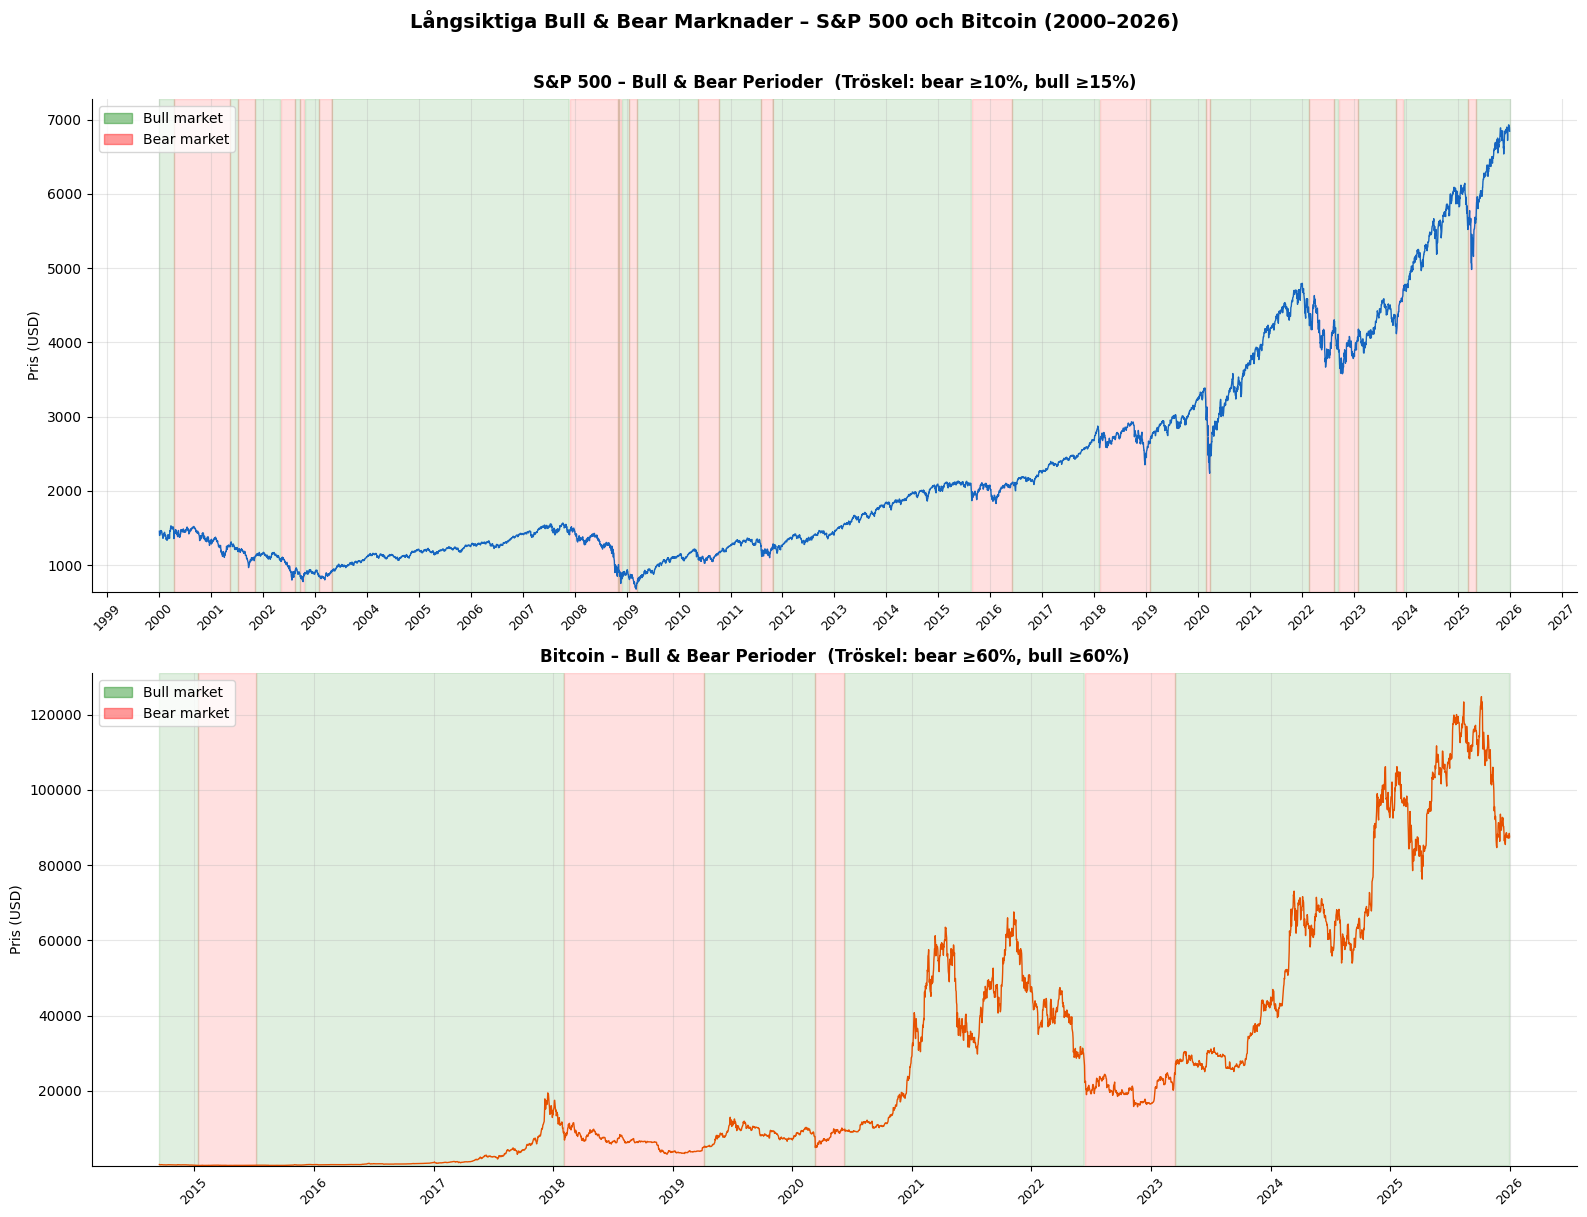

✓ Graf sparad: results/02_bull_bear_regimes.png


In [14]:
colors     = {'SP500': '#1565C0', 'Bitcoin': '#E65100'}
labels_map = {'SP500': 'S&P 500', 'Bitcoin': 'Bitcoin'}

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False)

for ax, (name, df) in zip(axes, assets.items()):
    close  = df['Close'].dropna()
    regime = df['Regime'].reindex(close.index)
    t      = THRESHOLDS[name]

    if name == 'Bitcoin':
        regime = label_regimes_min_days(
            close,
            bear_threshold=t['bear'],
            bull_threshold=t['bull'],
            min_days=90
        )
    else:
        regime = df['Regime'].reindex(close.index)

    # Färglägg bakgrund
    ax.fill_between(close.index, close.min() * 0.95, close.max() * 1.05,
                    where=(regime == 1), alpha=0.12, color='green')
    ax.fill_between(close.index, close.min() * 0.95, close.max() * 1.05,
                    where=(regime == 0), alpha=0.12, color='red')

    # Prisutveckling
    ax.plot(close.index, close, color=colors[name], linewidth=1)

    # Titel och labels
    ax.set_title(
        f'{labels_map[name]} – Bull & Bear Perioder  '
        f'(Tröskel: bear ≥{int(t["bear"]*100)}%, bull ≥{int(t["bull"]*100)}%)',
        fontsize=12, fontweight='bold', pad=8
    )
    ax.set_ylabel('Pris (USD)', fontsize=10)
    ax.set_ylim(close.min() * 0.95, close.max() * 1.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # X-axel
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=45, labelsize=9)

    # Legend
    bull_patch = mpatches.Patch(color='green', alpha=0.4, label='Bull market')
    bear_patch = mpatches.Patch(color='red',   alpha=0.4, label='Bear market')
    ax.legend(handles=[bull_patch, bear_patch], fontsize=10, loc='upper left')

fig.suptitle('Långsiktiga Bull & Bear Marknader – S&P 500 och Bitcoin (2000–2026)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, '02_bull_bear_regimes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Graf sparad: results/02_bull_bear_regimes.png')

### Motivering av tillgångsspecifika trösklar

**S&P 500: bear ≥10%, bull ≥15%**

Vi följer Lunde & Timmermann (2004) som använder dessa asymmetriska trösklar 
för aktiemarknader. 10% nedgång fångar de verkliga strukturella bear markets:
- Dot-com-kraschen 2000–2002: -37%
- Finanskrisen 2008–2009: -49%
- Covid-kraschen 2020: -32%

**Bitcoin: bear ≥60%, bull ≥60%, min 90 dagar**

Bitcoins historiska bear markets har sett nedgångar på 77–86%:
- 2014–2015: -86%
- 2017–2018: -84%
- 2021–2022: -77%

En nedgång på 40–50% händer relativt ofta inom bull markets för Bitcoin – 
det är normalt brus. 60% fångar de verkliga strukturella bear markets och 
inte tillfälliga korrektioner. 90 dagars minimum motiveras av att 
Bitcoin-cyklerna är långa: bull markets varar ~1000 dagar och bear markets 
~365 dagar historiskt.

## 6. Identifiera specifika bull & bear perioder

Här listar vi de exakta datumen för varje regimskifte – användbart för metodkapitlet i rapporten.

In [15]:
def get_regime_periods(regime: pd.Series) -> pd.DataFrame:
    periods = []
    current = regime.iloc[0]
    start   = regime.index[0]

    for date, val in regime.items():
        if val != current:
            periods.append({
                'Typ':   'Bull' if current == 1 else 'Bear',
                'Start': start.date(),
                'Slut':  date.date(),
                'Dagar': (date - start).days
            })
            current = val
            start   = date

    periods.append({
        'Typ':   'Bull' if current == 1 else 'Bear',
        'Start': start.date(),
        'Slut':  regime.index[-1].date(),
        'Dagar': (regime.index[-1] - start).days
    })

    return pd.DataFrame(periods)


for name, df in assets.items():
    print(f'\n── {name} ──────────────────────────────────────')
    periods = get_regime_periods(df['Regime'].dropna())
    display(periods.style.map(
        lambda x: 'background-color: #c8e6c9' if x == 'Bull'
                  else ('background-color: #ffcdd2' if x == 'Bear' else ''),
        subset=['Typ']
    ))


── SP500 ──────────────────────────────────────


,Typ,Start,Slut,Dagar
0,Bull,2000-01-03,2000-04-14,102
1,Bear,2000-04-14,2001-05-16,397
2,Bull,2001-05-16,2001-07-10,55
3,Bear,2001-07-10,2001-11-06,119
4,Bull,2001-11-06,2002-05-06,181
5,Bear,2002-05-06,2002-08-14,100
6,Bull,2002-08-14,2002-09-19,36
7,Bear,2002-09-19,2002-10-21,32
8,Bull,2002-10-21,2003-01-30,101
9,Bear,2003-01-30,2003-05-02,92



── Bitcoin ──────────────────────────────────────


,Typ,Start,Slut,Dagar
0,Bull,2014-09-17,2015-01-14,119
1,Bear,2015-01-14,2015-07-11,178
2,Bull,2015-07-11,2018-02-05,940
3,Bear,2018-02-05,2019-04-07,426
4,Bull,2019-04-07,2020-03-12,340
5,Bear,2020-03-12,2020-06-10,90
6,Bull,2020-06-10,2022-06-12,732
7,Bear,2022-06-12,2023-03-17,278
8,Bull,2023-03-17,2025-12-31,1020


## 7. Beräkna daglig avkastning

Vi beräknar den dagliga procentuella förändringen i stängningspriset.  
Daglig avkastning används som feature i ML-modellerna och för statistisk analys.

In [16]:
for name, df in assets.items():
    assets[name]['Return'] = df['Close'].pct_change()

    bull_ret = df.loc[df['Regime'] == 1, 'Return'].mean() * 100
    bear_ret = df.loc[df['Regime'] == 0, 'Return'].mean() * 100

    print(f'{name}:')
    print(f'  Genomsnittlig daglig avkastning – Bull: {bull_ret:+.3f}%  Bear: {bear_ret:+.3f}%')

SP500:
  Genomsnittlig daglig avkastning – Bull: +0.056%  Bear: -0.040%
Bitcoin:
  Genomsnittlig daglig avkastning – Bull: +0.231%  Bear: +0.057%


### Analys av daglig avkastning per regime

**S&P 500** visar det förväntade mönstret: bull-dagar har positiv genomsnittlig 
avkastning (+0.063%) medan bear-dagar är negativa (-0.040%). LT-algoritmen med 
10%/15%-trösklar ger väldefinierade regimer där bear-perioder netto är förlustskapande.

**Bitcoin** visar Bull: +0.231% mot Bear: +0.057%. Bear-avkastningen är positiv
eftersom LT-algoritmen med 60%-trösklar definierar bear-perioder som sträcker sig
från krasch ända tills priset återhämtat sig 60% från botten – återhämtningsfasen
ingår alltså i bear-perioden och höjer genomsnittet. Med min_days=90 filtreras
korta falsklarm bort, vilket ger en renare bear-signal. Skillnaden är ändå tydlig:
bull-avkastningen är ~4× högre per dag än under bear-perioder.


Detta är ett känt problem med regelbaserad etikettering: etiketterna är bakåtblickande 
och kan inte fastställas i realtid. Det påverkar dock inte ML-modellernas träning 
negativt — modellerna lär sig att förutsäga regimetiketter baserat på features, 
inte daglig avkastning. Anomalin dokumenteras här för transparens.

## 8. Spara etiketterad data

In [17]:
for name, df in assets.items():
    filename = f'{name.lower()}_labeled.csv'
    filepath = os.path.join(DATA_DIR, filename)
    df.to_csv(filepath)
    print(f'✓ Sparad: data/{filename}  ({len(df)} rader, kolumner: {list(df.columns)})')

✓ Sparad: data/sp500_labeled.csv  (6539 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return'])
✓ Sparad: data/bitcoin_labeled.csv  (4124 rader, kolumner: ['Open', 'High', 'Low', 'Close', 'Volume', 'Regime', 'Return'])


## 9. Sammanfattning

| Tillgång | Bull-dagar | Bear-dagar | Bull % | Bear % |
|----------|-----------|-----------|--------|--------|
| S&P 500  | 4830      | 1709      | 73.9%  | 26.1%  |
| Bitcoin  | 3152      | 972       | 76.4%  | 23.6%  |

**Trösklar som används:**

| Tillgång | Bear-tröskel | Bull-tröskel | Min. varaktighet |
|----------|-------------|-------------|-----------------|
| S&P 500  | -10%        | +15%        | –               |
| Bitcoin  | -60%        | +60%        | 90 dagar        |

**Viktiga observationer:**
- S&P 500 är i bull market ~74% av perioden 2000–2026, vilket speglar en historiskt stark bull-period med tydliga bear-marknader vid dot-com, finanskrisen 2008 och covid 2020
- Bitcoin visar tydliga cykliska mönster kopplade till halveringarna med ~76% bull och ~24% bear
- De identifierade bear-perioderna stämmer väl med kända händelser: COVID-19 (mars 2020), kryptovintern (2018), FTX-kollaps (2022)

**Nästa steg:** `03_feature_engineering.ipynb` – skapa tekniska indikatorer och features för ML-modellerna.

